In [1]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data = Path("data_bak")

In [3]:
data_i_data = os.listdir(data)
data_i_data.sort()
data_i_data

['.ipynb_checkpoints',
 'age_group_death_weights.csv',
 'asfr_norm_avg.csv',
 'befolkningsutvikling_2023_2026_1_3-2_1-1_5.csv',
 'befolkningsutvikling_2023_2123_1_3-2_1.csv',
 'befolkningsutvikling_2023_2123_1_5.csv',
 'befolkningsutvikling_2113_2123_1_5_v2.csv',
 'popfordeling_2023-2023_tfr1_5.csv',
 'popfordeling_2023-2026_tfr1_3.csv',
 'popfordeling_2023-2026_tfr1_5.csv',
 'popfordeling_2023-2026_tfr2_1.csv',
 'popfordeling_2023-2033_tfr1_5.csv',
 'popfordeling_2023-2123_tfr1_3.csv',
 'popfordeling_2023-2123_tfr1_5.csv',
 'popfordeling_2023-2123_tfr2_1.csv',
 'popfordeling_2033-2043_tfr1_5.csv',
 'popfordeling_2043-2053_tfr1_5.csv',
 'popfordeling_2043-2140_tfr2_1.csv',
 'popfordeling_2053-2063_tfr1_5.csv',
 'popfordeling_2063-2073_tfr1_5.csv',
 'popfordeling_2063-2140_tfr2_1.csv',
 'popfordeling_2073-2083_tfr1_5.csv',
 'popfordeling_2083-2093_tfr1_5.csv',
 'popfordeling_2083-2140_tfr2_1.csv',
 'popfordeling_2093-2103_tfr1_5.csv',
 'popfordeling_2103-2113_tfr1_5.csv',
 'popfordeling

In [12]:
df = pd.read_csv('data/populasjon_2123_tfr1_5.csv')
df

,sex,alder,barn
0,M,100.0,1.0
1,M,100.0,1.0
2,M,100.0,0.0
3,M,100.0,0.0
4,M,100.0,0.0
...,...,...,...
3119647,K,0.0,0.0
3119648,M,0.0,0.0
3119649,K,0.0,0.0
3119650,K,0.0,0.0


/tmp/ipykernel_194377/2730122490.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_194377/2730122490.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(abs(tick)) for tick in ticks])


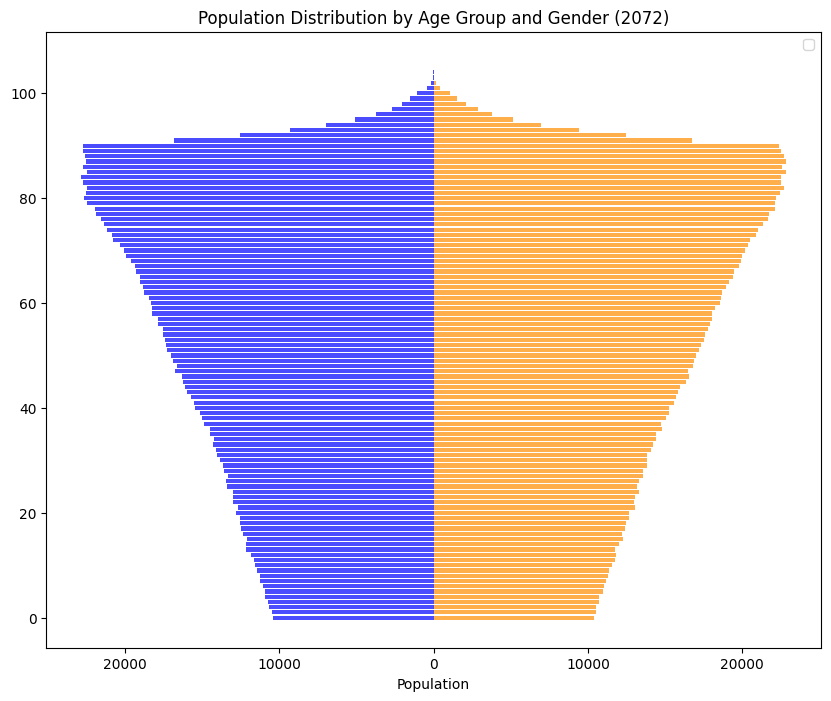

In [13]:
i = 2023 + 49
alpha = 0.7

to_plot = df.groupby(["alder", "sex"]).barn.count().sort_index().reset_index().rename(columns={"barn":f"pop_{i}"})
                                                                                     
fig, ax = plt.subplots(figsize=(10, 8))
to_plot_m = to_plot[["alder", "sex", f"pop_{i}"]].loc[lambda x: x.sex == "M"]
to_plot_k = to_plot[["alder","sex", f"pop_{i}"]].loc[lambda x: x.sex == "K"]
to_plot_k[f"pop_{i}"] = - to_plot_k[f"pop_{i}"]  
# Plotting


ax.barh(to_plot_m['alder'], to_plot_m[f"pop_{i}"], color='darkorange', alpha=alpha)
ax.barh(to_plot_k['alder'], to_plot_k[f"pop_{i}"], color='blue', alpha=alpha)


ax.set_xlabel('Population')
ax.set_title(f'Population Distribution by Age Group and Gender ({i})')
ax.legend()

# Customizing the x-axis to show positive values for both sides
ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(tick)) for tick in ticks])
#plt.savefig(bilder / f"{i}.jpg", format="jpg", dpi=50)
plt.show()

In [16]:
pop_fordeling = pd.read_csv("data/popfordeling_2023-2123_tfr1_5.csv")
år_start = 2023
år_slutt = år_start + 100

In [17]:
from pathlib import Path
bilder = Path("Figures") / "aldersfordeling_ny"
alpha = 0.7
tidsperiode = range(år_start, år_slutt)

for i in tidsperiode:
    print((i-2023)/len(tidsperiode))
    fig, ax = plt.subplots(figsize=(10, 8))
    to_plot_m = pop_fordeling[["alder", "sex", f"pop_{i}"]].loc[lambda x: x.sex == "M"]
    to_plot_k = pop_fordeling[["alder","sex", f"pop_{i}"]].loc[lambda x: x.sex == "K"]
    to_plot_k[f"pop_{i}"] = - to_plot_k[f"pop_{i}"]  
    # Plotting
    

    ax.barh(to_plot_m['alder'], to_plot_m[f"pop_{i}"], color='darkorange', alpha=alpha, label = "Men")
    ax.barh(to_plot_k['alder'], to_plot_k[f"pop_{i}"], color='blue', alpha=alpha, label ="Women")
    
  
    ax.set_xlabel('Population')
    ax.set_title(f'Population Distribution by Age Group and Gender ({i})')
    ax.legend()

    # Customizing the x-axis to show positive values for both sides
    #ticks = ax.get_xticks()
    ticks = [-50000, -40000, -30000, -20000, -10000, 0, 10000, 20000, 30000, 40000, 50000]
    ax.set_xticks(ticks)
   # print(ticks)
    ax.set_xticklabels([int(abs(tick)) for tick in ticks])
    plt.ylim(0, 110)
    
    plt.savefig(bilder / f"{i}.jpg", format="jpg", dpi=50)
    plt.close()
    #plt.show()

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


In [12]:
# Create dataframes
df1 = pd.DataFrame(befolkning_for_2023).loc[lambda x: x.år < 2024]
df2 = pd.DataFrame(befolkningsutvikling)


# Function to generate random color
def get_random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

plt.figure(figsize=(10, 6))

plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')

    # Plotting
for tfr in tfrs:
    # Vi plotter linjer for de ulike TFRene i datarammen.
    label2 = f"Prediction from {år_start}-{år_slutt} with TFR={tfr}"

    # Line for 2025 to 2055
    plt.plot(df2['år'], df2[f'pop_{tfr}'], label=label2, color=get_random_color())

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('Population Development from 1986 to 2055')
plt.legend()

# Show plot
plt.show()


NameError: name 'befolkning_for_2023' is not defined

In [306]:
df

,sex,alder,barn,aldersgruppe
0,M,100,0,100+
1,M,100,0,100+
2,M,100,0,100+
3,M,100,0,100+
4,M,100,0,100+
...,...,...,...,...
3410395,M,11,0,NaN
3410396,K,28,0,NaN
3410397,K,77,3,NaN
3410398,K,6,0,NaN


In [328]:
pop_fordeling

,sex,alder,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,...,pop_2114,pop_2115,pop_2116,pop_2117,pop_2118,pop_2119,pop_2120,pop_2121,pop_2122,pop_2123
0,K,0,25310.0,27237.0,27107.0,26721.0,27079.0,26896.0,26555.0,26526.0,...,13744.0,13482.0,13284.0,13307.0,13138.0,12866.0,12764.0,12704.0,12424.0,12490.0
1,K,1,28037.0,25510.0,27435.0,27257.0,26892.0,27237.0,27054.0,26696.0,...,13715.0,13744.0,13482.0,13287.0,13307.0,13138.0,12866.0,12766.0,12704.0,12426.0
2,K,2,26820.0,28231.0,25702.0,27637.0,27416.0,27037.0,27372.0,27212.0,...,13734.0,13716.0,13746.0,13482.0,13288.0,13311.0,13143.0,12868.0,12767.0,12705.0
3,K,3,27466.0,27035.0,28409.0,25889.0,27826.0,27582.0,27152.0,27521.0,...,14087.0,13739.0,13718.0,13746.0,13485.0,13287.0,13312.0,13143.0,12868.0,12767.0
4,K,4,27692.0,27664.0,27246.0,28579.0,26061.0,27986.0,27730.0,27299.0,...,14151.0,14088.0,13741.0,13719.0,13746.0,13487.0,13289.0,13313.0,13144.0,12868.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,28.0,NaN,5.0,2.0,1.0,1.0,2.0,1.0,...,14.0,9.0,6.0,8.0,4.0,6.0,8.0,8.0,4.0,7.0
216,M,106,NaN,10.0,NaN,2.0,NaN,NaN,1.0,1.0,...,4.0,5.0,4.0,4.0,3.0,1.0,2.0,2.0,6.0,NaN
217,M,107,NaN,NaN,3.0,NaN,1.0,NaN,NaN,1.0,...,2.0,2.0,3.0,3.0,3.0,NaN,NaN,NaN,1.0,4.0
218,M,108,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN


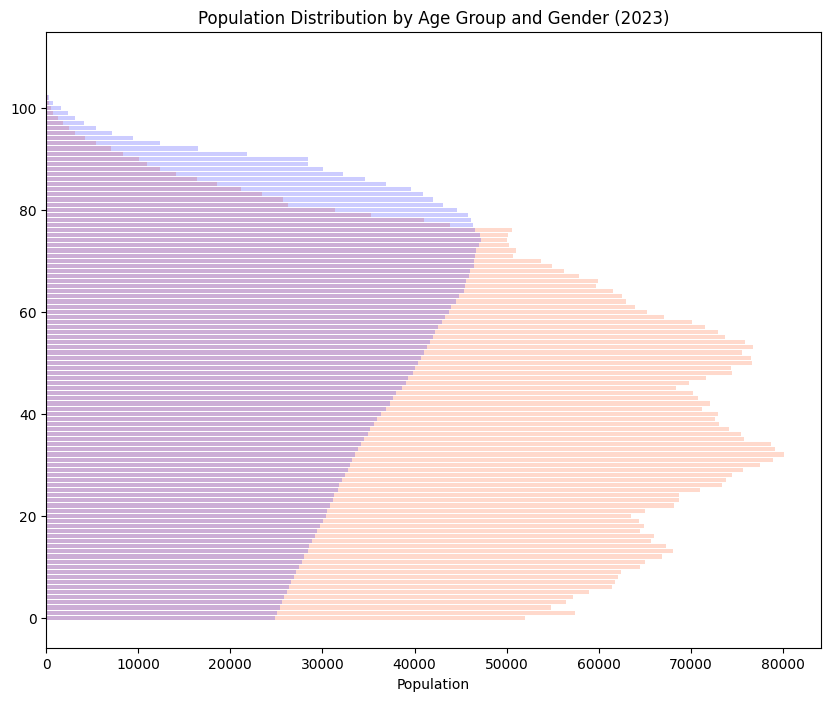

In [334]:
# Plotting
df_er = pop_fordeling[["alder", f"pop_{2023}"]].groupby("alder").pop_2023.sum().reset_index()
df_fr = pop_fordeling[["alder", f"pop_{2023+100}"]].groupby("alder").pop_2123.sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(y=df_er["alder"], width=df_er["pop_2023"], color='orangered', alpha=0.2, label=f'Population {2023}')
ax.barh(df_fr['alder'], df_fr[f"pop_{2023+100}"], color='blue', alpha=0.2, label=f'Population {2023+100}')

ax.set_xlabel('Population')
ax.set_title('Population Distribution by Age Group and Gender (2023)')
#ax.legend()

# Customizing the x-axis to show positive values for both sides
#ticks = ax.get_xticks()
#ax.set_xticklabels([int(abs(tick)) for tick in ticks])

plt.show()

In [336]:
# Demonstrasjon av Norge
ny_befolkning_etter = pd.DataFrame()
start_pop = start_pop
år_start = år_slutt
år = 50
år_slutt = år_start + år
yngste_fodsel = 15
eldste_fødsel = 49
ny_befolkning_etter["år"] = range(år_start, år_slutt+1)
# befolkningsutvikling


In [342]:
df_for_run

,sex,alder,barn,aldersgruppe
0,M,102,0,100+
1,M,102,0,100+
2,M,102,0,100+
3,M,102,0,100+
4,M,102,0,100+
...,...,...,...,...
3410395,M,13,0,NaN
3410396,K,30,0,NaN
3410397,K,79,3,NaN
3410398,K,8,0,NaN
